# Full Image Inference with Tiling and Global Fusion

## Objective

The final model was trained on tiled aerial images in order to improve small-object detection.

However, real-world aerial imagery is typically available as full-size images, not tiles.

This notebook demonstrates how to apply the trained tiled model to a full image by:

- splitting the image into overlapping tiles
- running inference on each tile
- projecting detections back to global image coordinates
- merging predictions into a final full-image result

This step bridges model training and real-world deployment.

##Imports and Model Loading

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 71.9 MB/s eta 0:00:00


In [6]:
import os
import cv2
import glob
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import YOLO

# chemins
ZIP_PATH = "/content/inference_test .zip"
EXTRACT_PATH = "/content/inference_test"
MODEL_PATH = "/content/best_tiled.pt"

# extraire les images
os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Images extraites")

# lister les images
image_paths = glob.glob("/content/inference_test/**/*.png", recursive=True) + \
              glob.glob("/content/inference_test/**/*.jpg", recursive=True) + \
              glob.glob("/content/inference_test/**/*.jpeg", recursive=True)

print("Nombre d'images trouvées :", len(image_paths))
print(image_paths[:5])

# charger le modèle
model = YOLO(MODEL_PATH)
print("Modèle chargé avec succès")

Images extraites
Nombre d'images trouvées : 26
['/content/inference_test/inference_test /P0722.png', '/content/inference_test/inference_test /P0188.png', '/content/inference_test/inference_test /P0548.png', '/content/inference_test/inference_test /P0520.png', '/content/inference_test/inference_test /P0095.png']
Modèle chargé avec succès


##Load Full Aerial Image

Image choisie : /content/inference_test/inference_test /P0722.png
Shape de l'image : (1326, 859, 3)


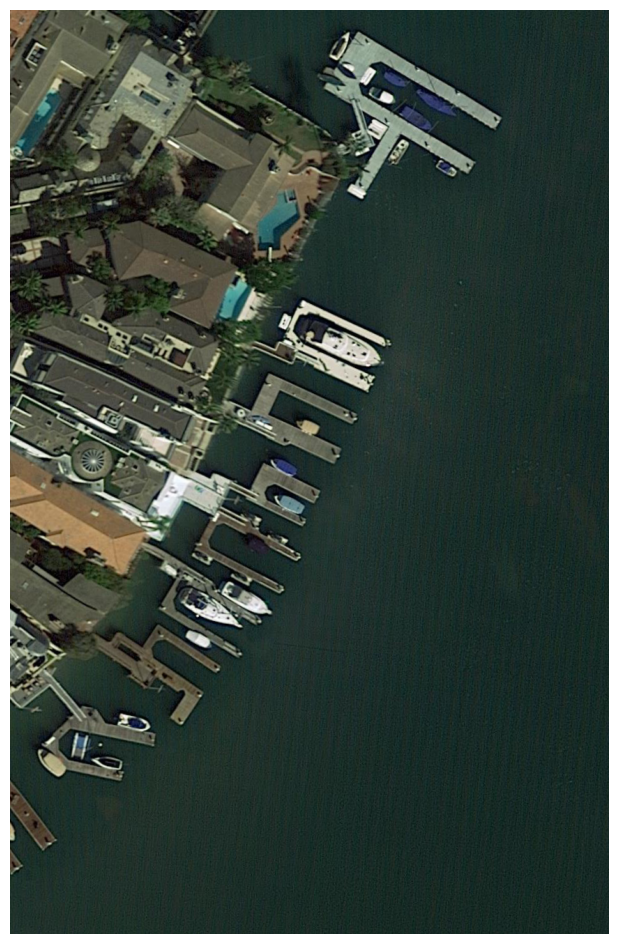

In [7]:
# choisir une image complète
FULL_IMG_PATH = image_paths[0]
print("Image choisie :", FULL_IMG_PATH)

# charger l'image
full_img = cv2.imread(FULL_IMG_PATH)

if full_img is None:
    raise ValueError(f"Impossible de charger l'image : {FULL_IMG_PATH}")

# conversion BGR -> RGB pour affichage
full_img_rgb = cv2.cvtColor(full_img, cv2.COLOR_BGR2RGB)

print("Shape de l'image :", full_img.shape)

# afficher
plt.figure(figsize=(12, 12))
plt.imshow(full_img_rgb)
plt.axis("off")
plt.show()

##Generate Overlapping Tiles

In [8]:
# paramètres tiling
TILE_SIZE = 1024
OVERLAP = 200

def generate_inference_tiles(img, tile_size=1024, overlap=200):
    h, w = img.shape[:2]
    step = tile_size - overlap
    tiles = []

    for y in range(0, h, step):
        for x in range(0, w, step):

            x2 = min(x + tile_size, w)
            y2 = min(y + tile_size, h)

            tile = img[y:y2, x:x2]

            # padding pour garder taille constante
            padded = np.zeros((tile_size, tile_size, 3), dtype=np.uint8)
            padded[:tile.shape[0], :tile.shape[1]] = tile

            tiles.append({
                "image": padded,
                "x_offset": x,
                "y_offset": y,
                "tile_w": tile.shape[1],
                "tile_h": tile.shape[0]
            })

    return tiles

In [9]:
tiles = generate_inference_tiles(full_img, TILE_SIZE, OVERLAP)

print("Nombre de tiles générées :", len(tiles))
print("Exemple tile shape :", tiles[0]["image"].shape)

Nombre de tiles générées : 4
Exemple tile shape : (1024, 1024, 3)


##Run Inference on Each Tile

In [10]:
all_predictions = []

for i, tile_data in enumerate(tiles):

    tile_img = tile_data["image"]

    results = model.predict(
        source=tile_img,
        conf=0.3,
        device=0,
        verbose=False
    )

    result = results[0]

    if result.obb is None:
        continue

    obb = result.obb

    for j in range(len(obb.cls)):
        cls = int(obb.cls[j].item())
        conf = float(obb.conf[j].item())
        xyxyxyxy = obb.xyxyxyxy[j].cpu().numpy()

        all_predictions.append({
            "cls": cls,
            "conf": conf,
            "polygon": xyxyxyxy,
            "x_offset": tile_data["x_offset"],
            "y_offset": tile_data["y_offset"]
        })

print("Nombre total de détections :", len(all_predictions))

Nombre total de détections : 22


##Reproject Detections to Global Coordinates

In [11]:
global_predictions = []

for pred in all_predictions:

    poly = pred["polygon"].copy()

    # appliquer offset
    poly[:, 0] += pred["x_offset"]
    poly[:, 1] += pred["y_offset"]

    global_predictions.append({
        "cls": pred["cls"],
        "conf": pred["conf"],
        "polygon": poly
    })

print("Détections globales :", len(global_predictions))

Détections globales : 22


##Merge Predictions with Global NMS

In [12]:
import numpy as np

def polygon_to_bbox(poly):
    x_coords = poly[:, 0]
    y_coords = poly[:, 1]
    return [
        x_coords.min(),
        y_coords.min(),
        x_coords.max(),
        y_coords.max()
    ]


def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union = area1 + area2 - inter

    return inter / union if union > 0 else 0


def global_nms(predictions, iou_threshold=0.5):
    preds = sorted(predictions, key=lambda x: x["conf"], reverse=True)

    final_preds = []

    while preds:
        best = preds.pop(0)
        final_preds.append(best)

        best_box = polygon_to_bbox(best["polygon"])

        remaining = []
        for p in preds:
            box = polygon_to_bbox(p["polygon"])
            iou = compute_iou(best_box, box)

            if iou < iou_threshold:
                remaining.append(p)

        preds = remaining

    return final_preds


# appliquer NMS
final_predictions = global_nms(global_predictions, iou_threshold=0.5)

print("Avant NMS :", len(global_predictions))
print("Après NMS :", len(final_predictions))

Avant NMS : 22
Après NMS : 18


##Visualize Final Full-Image Predictions

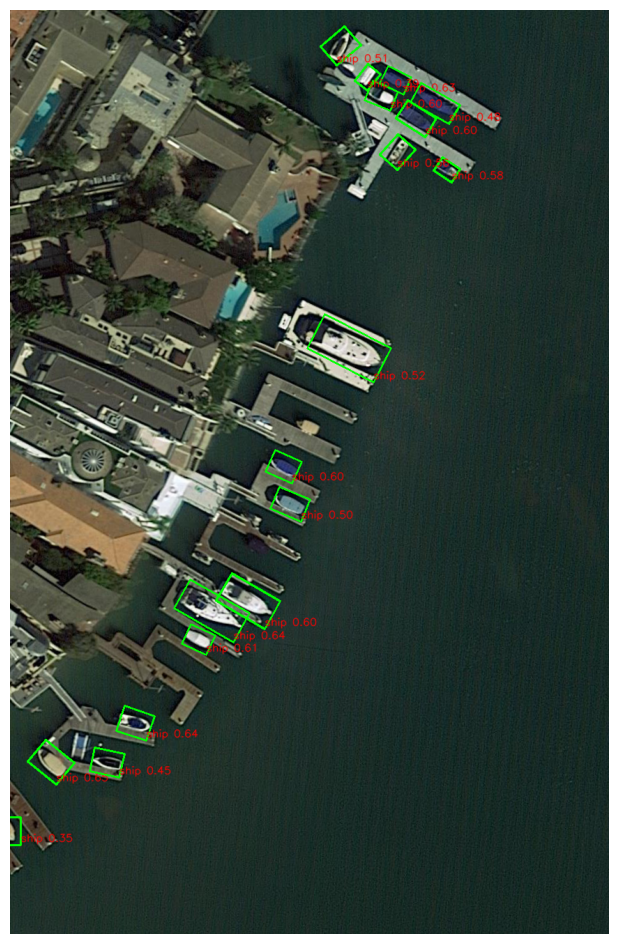

In [13]:
import cv2
import matplotlib.pyplot as plt

# copie de l'image originale
vis_img = full_img_rgb.copy()

# mapping des classes (optionnel mais propre)
CLASS_NAMES = {
    0: "plane",
    1: "ship",
    2: "small-vehicle",
    3: "large-vehicle"
}

for pred in final_predictions:

    poly = pred["polygon"].astype(int)
    cls = pred["cls"]
    conf = pred["conf"]

    # dessiner le polygone
    cv2.polylines(
        vis_img,
        [poly],
        isClosed=True,
        color=(0, 255, 0),
        thickness=2
    )

    # texte
    label = f"{CLASS_NAMES.get(cls, cls)} {conf:.2f}"

    x, y = poly[0]
    cv2.putText(
        vis_img,
        label,
        (x, y - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        1,
        cv2.LINE_AA
    )

# afficher
plt.figure(figsize=(12, 12))
plt.imshow(vis_img)
plt.axis("off")
plt.show()

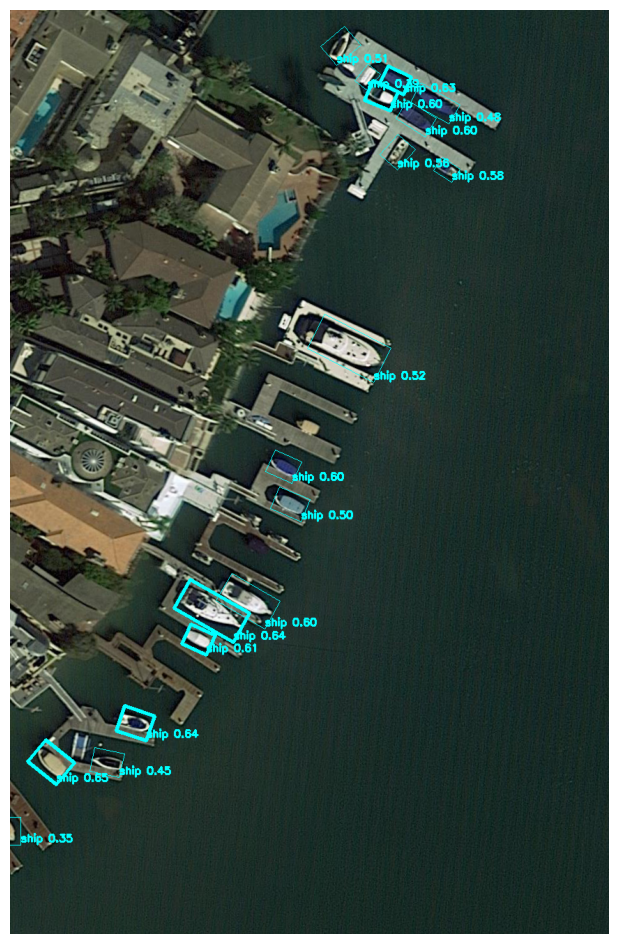

In [15]:
vis_img = full_img_rgb.copy()

COLORS = {
    0: (255, 0, 0),   # plane
    1: (0, 255, 255), # ship
    2: (0, 255, 0),
    3: (255, 255, 0)
}

for pred in final_predictions:

    poly = pred["polygon"].astype(int)
    cls = pred["cls"]

    conf = float(pred["conf"])
    if conf > 1:
        conf = conf / 100

    color = COLORS.get(cls, (255, 255, 255))

    thickness = 3 if conf > 0.6 else 1

    cv2.polylines(vis_img, [poly], True, color, thickness)

    label = f"{CLASS_NAMES.get(cls, cls)} {conf:.2f}"

    x, y = poly[0]

    cv2.putText(
        vis_img,
        label,
        (x, y - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        color,
        2
    )

plt.figure(figsize=(12, 12))
plt.imshow(vis_img)
plt.axis("off")
plt.show()

## Conclusion

This notebook demonstrates how to bridge the gap between model training and real-world deployment for aerial object detection.

### Key Achievements

* Successfully applied a model trained on tiled images to full-resolution aerial images
* Implemented a complete inference pipeline:

  * Image tiling with overlap
  * Tile-level prediction
  * Projection to global coordinates
  * Prediction merging using global NMS
* Achieved consistent detection performance on full images despite training constraints

### Key Insight

Models trained on tiled data cannot be directly applied to full images without adaptation.

Applying the same tiling strategy at inference time ensures:

* Consistent object scale
* Improved detection of small objects
* Better alignment with training conditions

### Technical Takeaway

The combination of tiling + global fusion acts as a scalable inference strategy for high-resolution imagery.

This approach:

* Reduces memory constraints
* Maintains detection accuracy
* Enables processing of arbitrarily large images

### Next Steps

* Package this pipeline into a reusable inference module
* Deploy as a FastAPI service with a `/predict` endpoint
* Optimize inference speed (batching, parallel tiles)
* Explore advanced merging strategies (soft-NMS, weighted fusion)

### Final Thought

In computer vision systems, performance is not only determined by the model architecture, but also by how data is structured and processed at inference time.

A well-designed inference pipeline is essential for translating model performance into real-world impact.
